In [1]:
# import dependencies
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

# suppress warning
import warnings

warnings.filterwarnings("ignore", message="When grouping with a length-1 list-like")

### Quadrant Model Comparison & Correlation Analysis Summary

- Cleaned and preprocessed Vermont town-level data, including winsorizing outliers, filling missing values, and filtering out zero-population towns.
- Built multiple model specifications for estimating "need" using combinations of risk and vulnerability variables, with rank-based normalization for comparability:
    - Core Expected Annual Loss (EAL) (expected loss)
    - Simple exposure (river corridor)
    - EAL per capita (population-normalized risk)
    - FEMA National Risk Index (NRI) risk + vulnerability indices
- Computed a gap index (funding minus need) to identify towns that are over- or underfunded relative to estimated need.
- Assigned each town to a funding/need quadrant (zero funding, underfunded, aligned, overfunded, low priority) based on median splits.
- Summarized the distribution of towns across quadrants and analyzed the prevalence of zero funding among high- and low-need towns.
- Visualized the distribution of need and funding, and compared key variables across quadrants using boxplots and scatterplots.
- Mapped the geographic distribution of quadrant assignments for each model, using custom color schemes for clarity.
- Conducted sanity checks confirming that need indices are only weakly correlated with funding and claims (indicating allocation inefficiency), are not dominated by population, and checking insurance penetration as a contextual indicator.
- Compared the top 20 most underfunded towns across models to assess the stability and overlap of results.
- Calculated and visualized the Spearman correlation matrix for need indices across all models, providing a diagnostic of model agreement and robustness.
- All visualizations and diagnostics support transparent comparison of model outputs and highlight the influence of modeling choices on funding alignment assessments.

### Key Findings from Quadrant Model Comparison & Correlation Analysis

- A majority of towns (~52%) receive **zero funding** across all model specifications, indicating that **access to funding is the dominant structural feature** of the system.
- **High-need towns** are consistently **less likely to receive zero funding than low-need towns**, suggesting **some degree of targeting**; however, a substantial share of high-need towns still receive no funding, pointing to **incomplete or uneven access**.
- Among towns that do receive funding, the **relationship between need and funding is weak**, indicating limited alignment between estimated need and allocation intensity.
- The distribution of towns across quadrants is relatively stable, with most non-zero-funded towns falling into “aligned” or “underfunded” categories, and fewer in “overfunded” or “low priority.”
- The share of underfunded towns varies meaningfully by model, with EAL-based models identifying more underfunding, suggesting stronger differentiation in risk signal.
- Need indices are only moderately correlated across models (Spearman ~0.1–0.56), indicating that **model choice** (especially the definition of risk) **substantially affects town-level rankings**.
- Overlap among the top 20 most underfunded towns is limited, confirming that **targeting conclusions and policy recommendations are sensitive to modeling assumptions**.
- The model using **Expected Annual Loss (EAL)** produces **stronger and more differentiated signals** than a simpler exposure measure, while the FEMA-based National Risk Index (NRI) shows weaker alignment with other specifications.
- The EAL per capita model introduces population normalization effects, resulting in different prioritization patterns and slightly weaker alignment with other models.
- Sanity checks show that:
    - **Need** is **not driven by population**, supporting validity of per capita and rank-based scaling.
    - Need has a **modest positive relationship with insurance claims**, suggesting it captures real risk exposure to some extent.
    - Insurance penetration is extremely low statewide, limiting its usefulness as a validation metric but reinforcing underinsurance as a systemic issue rather than one concentrated in specific types of towns.
- Spatial patterns of funding alignment show geographic clustering, but these patterns shift depending on the risk specification, further highlighting model sensitivity.
- Overall, results indicate that:
    - Access to funding is the **primary bottleneck**
    - Allocation conditional on funding is only **weakly aligned** with need
    - **Model choice** meaningfully affects identification of underfunded communities, especially through the definition of risk

In [2]:
# open csv file
df = pd.read_csv("../data/cleaned/town_level_merged_for_eda.csv")

# open geojson file
gdf = gpd.read_file("../data/cleaned/census.geojson")

In [3]:
# data cleaning and preprocessing

# cap extreme outliers in poverty variable (winsorize)
df["pct_below_poverty"] = df["pct_below_poverty"].clip(
    upper=df["pct_below_poverty"].quantile(0.99)
)

# fill funding and claims NaNs with 0
cols_to_fill = [
    "funding_per_capita",
    "log_funding_per_capita",
    "funding_per_occupied_unit",
    "log_funding_per_occupied_unit",
    "claims_paid_per_capita",
    "current_insurance_penetration",
]
df[cols_to_fill] = df[cols_to_fill].fillna(0)

# drop towns with zero population (to avoid issues with per capita calculations and log transformations)
df = df[df["total_population"] > 0]

In [4]:
# functions for building indices


# def z_normalize(df, cols):
#     """
#     Apply z-score normalization to specified columns in a DataFrame.

#     Args:
#         df (pd.DataFrame): Input DataFrame.
#         cols (list): List of column names to normalize.

#     Returns:
#         pd.DataFrame: DataFrame with specified columns z-normalized.
#     """
#     df = df.copy()
#     scaler = StandardScaler()
#     df[cols] = scaler.fit_transform(df[cols])
#     return df


def rank_normalize(df, cols):
    """
    Apply rank-based normalization (percentile ranks) to specified columns in a DataFrame.

    Args:
        df (pd.DataFrame): Input DataFrame.
        cols (list): List of column names to normalize.

    Returns:
        pd.DataFrame: DataFrame with specified columns rank-normalized.
    """
    df = df.copy()
    for col in cols:
        df[col] = df[col].rank(pct=True)
    return df


def build_index(
    df, risk_vars, vuln_vars, funding_var, method="rank", log_funding=False
):
    """
    Build risk, vulnerability, and need indices, and compute funding gap.

    Args:
        df (pd.DataFrame): Input DataFrame.
        risk_vars (list): List of risk variable column names.
        vuln_vars (list): List of vulnerability variable column names.
        funding_var (str): Column name for funding variable.
        method (str): Normalization method ("z" or "rank").
        log_funding (bool): Whether to log-transform the funding variable.

    Returns:
        pd.DataFrame: DataFrame with new index and gap columns.
    """
    df = df.copy()

    all_vars = risk_vars + vuln_vars

    # normalize risk and vulnerability variables using specified method
    if all_vars:
        df_norm = (
            z_normalize(df, all_vars) if method == "z" else rank_normalize(df, all_vars)
        )
    else:
        df_norm = df.copy()

    # calculate risk and vulnerability indices as the mean of their respective (z-scored) variables
    df["risk_index"] = df_norm[risk_vars].mean(axis=1) if risk_vars else 0
    df["vuln_index"] = df_norm[vuln_vars].mean(axis=1) if vuln_vars else 0

    # combined need index (normalized 0–1-ish if rank, centered if z)
    df["need_index"] = (df["risk_index"] + df["vuln_index"]) / 2

    # # prepare funding series (optional log to reduce skew)
    # # safeguard - I've already log-transformed funding and filled NaNs in preprocessing
    funding = df[funding_var].fillna(0).copy()
    if log_funding:
        funding = np.log1p(funding)

    # scale funding to match chosen normalization method
    if method == "rank":
        # percentile ranks in ~[0,1] to match rank-based indices
        df["funding_scaled"] = funding.rank(pct=True)
    else:
        # z-score to match z-normalized indices (centered around 0)
        df["funding_scaled"] = (
            StandardScaler().fit_transform(funding.values.reshape(-1, 1)).ravel()
        )

    # gap: positive => overfunded relative to need; negative => underfunded
    df["gap_index"] = df["funding_scaled"] - df["need_index"]

    return df

In [5]:
# function to assign quadrants based on need and funding indices


def add_quadrants(df):
    """
    Add quadrant labels based on need and funding indices.
        Quadrants:
        - zero_funding: no funding regardless of need
        - underfunded: high need, low funding
        - aligned: high need, high funding
        - overfunded: low need, high funding
        - low_priority: low need, low funding

    Args:
        df (pd.DataFrame): Input DataFrame with 'need_index' and 'funding_scaled' columns.

    Returns:
        pd.DataFrame: DataFrame with an additional 'quadrant' column.
    """
    df = df.copy()

    # calculate median for need to define quadrants
    need_med = df["need_index"].median()

    df["quadrant"] = "unassigned"

    # zero funding = separate category regardless of need
    df.loc[df["funding_scaled"] == df["funding_scaled"].min(), "quadrant"] = (
        "zero_funding"
    )

    # get mask for non-zero funding to apply quadrant logic only to those rows
    mask = df["funding_scaled"] > df["funding_scaled"].min()

    # calculate median of non-zero funding for quadrant split
    fund_med_nonzero = df.loc[mask, "funding_scaled"].median()

    # assign quadrants based on need and funding relative to their medians
    df.loc[
        mask
        & (df["need_index"] >= need_med)
        & (df["funding_scaled"] < fund_med_nonzero),
        "quadrant",
    ] = "underfunded"
    df.loc[
        mask
        & (df["need_index"] >= need_med)
        & (df["funding_scaled"] >= fund_med_nonzero),
        "quadrant",
    ] = "aligned"
    df.loc[
        mask
        & (df["need_index"] < need_med)
        & (df["funding_scaled"] >= fund_med_nonzero),
        "quadrant",
    ] = "overfunded"
    df.loc[
        mask
        & (df["need_index"] < need_med)
        & (df["funding_scaled"] < fund_med_nonzero),
        "quadrant",
    ] = "low_priority"

    return df


def quadrant_summary(df):
    """
    Summarize counts and shares of each quadrant category.

    Args:
        df (pd.DataFrame): Input DataFrame with 'quadrant' column.

    Returns:
        pd.DataFrame: DataFrame with counts and shares of each quadrant category.
    """
    # calculate counts and shares of each quadrant category
    counts = df["quadrant"].value_counts()
    shares = df["quadrant"].value_counts(normalize=True)

    return pd.DataFrame({"count": counts, "share": shares}).reset_index()

In [6]:
# function to analyze zero funding patterns among high-need vs low-need towns


def zero_funding_analysis(df):
    """
    Analyze the share of high-need vs low-need towns that receive zero funding.

    Args:
        df (pd.DataFrame): Input DataFrame with 'need_index' and 'has_funding' columns.
    Returns:
        dict: Dictionary with shares of zero funding for high-need and low-need towns and the gap.
    """
    df = df.copy()
    # create binary indicator for zero funding
    df["zero_funding"] = df["has_funding"] == 0

    # define high-need vs low-need based on median need index
    need_med = df["need_index"].median()
    high_need = df["need_index"] >= need_med

    # calculate share of zero funding in high-need vs low-need groups, and the gap between them
    pct_high_need_zero = df.loc[high_need, "zero_funding"].mean()
    pct_low_need_zero = df.loc[~high_need, "zero_funding"].mean()
    gap = pct_high_need_zero - pct_low_need_zero

    # print results
    print(f"Share of high-need towns with zero funding: {pct_high_need_zero:.2%}")
    print(f"Share of low-need towns with zero funding: {pct_low_need_zero:.2%}")
    print(f"Difference: {gap:.2%}")

    return {
        "pct_high_need_zero": pct_high_need_zero,
        "pct_low_need_zero": pct_low_need_zero,
        "gap": gap,
    }


def zero_funding_breakdown(df):
    """
    Create a crosstab of high-need vs low-need towns and zero funding status.

    Args:
        df (pd.DataFrame): Input DataFrame with 'need_index' and 'has_funding' columns.

    Returns:
        pd.DataFrame: Crosstab of high-need vs low-need towns and zero funding status.
    """
    df = df.copy()

    # create binary indicator for zero funding
    df["zero_funding"] = df["has_funding"] == 0
    # define high-need vs low-need based on median need index
    df["high_need"] = df["need_index"] >= df["need_index"].median()

    # normalize by index to get percentages within high-need and low-need groups
    return pd.crosstab(df["high_need"], df["zero_funding"], normalize="index")

In [7]:
# functions for plotting results


def plot_need_funding_distributions(df_results, name=None):
    """
    Plot KDE distributions of need index and scaled funding for visual comparison.

    Args:
        df_results (pd.DataFrame): DataFrame containing 'need_index' and 'funding_scaled' columns.
    Returns:
        None (displays the plot).
    """
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df_results, x="need_index", label="Need")
    sns.kdeplot(data=df_results, x="funding_scaled", label="Funding")
    plt.legend()
    plt.title("Need vs Funding Distributions" + (f"\n({name})" if name else ""))
    plt.show()


def plot_quadrant_boxplots(df, vars_to_plot, name=None):
    """
    Create boxplots of specified variables by quadrant category.
    Args:
        df (pd.DataFrame): Input DataFrame with 'quadrant' column and variables to plot.
        vars_to_plot (list): List of column names to create boxplots for.
    Returns:
        None (displays the plots).
    """
    for var in vars_to_plot:
        # Plotly interactive boxplot
        fig = px.box(
            df,
            x="quadrant",
            y=var,
            hover_data=["town_name", "total_population"],
            title=f"{var} by Quadrant (Interactive)" + (f"\n({name})" if name else ""),
        )
        fig.show()

        # Matplotlib static boxplot
        plt.figure(figsize=(8, 6))
        sns.boxplot(data=df, x="quadrant", y=var)
        plt.title(f"{var} by Quadrant (Static)" + (f"\n({name})" if name else ""))
        plt.show()


def quadrant_scatter(df, name=None):
    """
    Create a scatter plot of funding vs. need colored by quadrant category.

    Args:
        df (pd.DataFrame): Input DataFrame with 'need_index', 'funding_scaled', and 'quadrant' columns.

    Returns:
        None (displays the plots).
    """
    # Plotly interactive scatter plot
    fig = px.scatter(
        df,
        x="need_index",
        y="funding_scaled",
        color="quadrant",
        hover_data=["town_name", "total_population"],
        title="Funding vs. Need Quadrant Analysis" + (f"\n({name})" if name else ""),
        labels={"need_index": "Need Index", "funding_scaled": "Scaled Funding"},
    )
    fig.add_vline(x=df["need_index"].median(), line_dash="dash", line_color="gray")
    fig.add_hline(y=df["funding_scaled"].median(), line_dash="dash", line_color="gray")
    fig.show()

    # Matplotlib static scatter plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x="need_index", y="funding_scaled", hue="quadrant")
    plt.axvline(x=df["need_index"].median(), color="gray", linestyle="--")
    plt.axhline(y=df["funding_scaled"].median(), color="gray", linestyle="--")
    plt.title("Funding vs. Need Quadrant Analysis" + (f"\n({name})" if name else ""))
    plt.show()


# plot geographic distribution of quadrants
def plot_quadrant_map(df, gdf, name=None, ax=None):
    """
    Plot a choropleth map of quadrant categories by town.

    Args:
        df (pd.DataFrame): Input DataFrame with 'GEOID', 'quadrant', and 'town_name' columns.
        gdf (gpd.GeoDataFrame): GeoDataFrame with geometries for each town.

    Returns:
        None (displays the maps).
    """

    df = df.copy()
    gdf = gdf.copy()

    # ensure GEOID is string for merging
    df["GEOID"] = df["GEOID"].astype(str)
    gdf["GEOID"] = gdf["GEOID"].astype(str)

    # merge quadrant info into geodataframe
    gdf = gdf.merge(
        df[["GEOID", "quadrant", "town_name"]],
        left_on="GEOID",
        right_on="GEOID",
        how="left",
    )

    # # Plotly interactive choropleth map
    # # commented out to keep file under GitHub's file size limit
    # fig = px.choropleth(
    #     gdf,
    #     geojson=gdf.geometry,
    #     locations=gdf.index,
    #     color="quadrant",
    #     hover_data=["town_name", "quadrant"],
    #     title="Geographic Distribution of Funding Alignment (Interactive)"
    # )
    # # center on Vermont and set appropriate zoom level
    # fig.update_geos(
    #     center={"lat": 44.0, "lon": -72.7},
    #     fitbounds="locations",
    #     visible=False,
    #     projection_scale=7
    # )
    # fig.show()

    # Matplotlib static map

    # mapping quadrants to colors
    quadrant_colors = {
        "zero_funding": "#888888",
        "underfunded": "#e41a1c",
        "aligned": "#377eb8",
        "overfunded": "#4daf4a",
        "low_priority": "#ff7f00",
    }

    # ensure quadrant column is a categorical with the correct order
    quadrant_order = list(quadrant_colors.keys())
    gdf["quadrant"] = pd.Categorical(gdf["quadrant"], categories=quadrant_order)

    # drop NAs and map colors to the data
    gdf_plot = gdf[~gdf["quadrant"].isna()].copy()
    colors = gdf_plot["quadrant"].map(quadrant_colors)

    # plot using the mapped colors
    gdf_plot.plot(
        # column="quadrant",
        legend=False,
        figsize=(10, 8) if ax is None else None,
        color=colors,
        ax=ax,
        edgecolor="black",
    )

    # custom legend
    handles = [
        mpatches.Patch(color=color, label=label)
        for label, color in quadrant_colors.items()
    ]
    plt.legend(
        handles=handles, title="Quadrant", bbox_to_anchor=(1.05, 1), loc="upper left"
    )

    # set title and turn off axes or show plot depending on whether we're using a provided axis
    if ax is not None:
        ax.set_title(
            f"Geographic Distribution of Funding Alignment\n{name}"
            if name
            else "Geographic Distribution of Funding Alignment"
        )
        ax.axis("off")
    else:
        plt.title(
            f"Geographic Distribution of Funding Alignment\n{name}"
            if name
            else "Geographic Distribution of Funding Alignment"
        )
        plt.show()

    # plt.show()

In [8]:
def analyze_models(df, model_specs, gdf=None, display_results=True):
    """
    Run the full analysis for each model specification, including index building, quadrant assignment, and result summarization.

    Args:
        df (pd.DataFrame): Input DataFrame with town-level data.
        model_specs (dict): Dictionary of model specifications with risk and vulnerability variable lists.
        gdf (gpd.GeoDataFrame, optional): GeoDataFrame for mapping. Defaults to None.
        display_results (bool, optional): Whether to display results and plots. Defaults to True.

    Returns:
        dict: Dictionary containing results for each model specification.
    """
    # initialize results dictionary
    results = {}

    # loop through model specifications and run analysis
    for name, spec in model_specs.items():
        print(f"=== {name} ===\n")
        # extract variable lists from spec
        risk_vars = spec.get("risk", [])
        vuln_vars = spec.get("vuln", [])
        funding_var = "log_funding_per_capita"

        # build indices and assign quadrants
        df_results = build_index(df, risk_vars, vuln_vars, funding_var, method="rank")
        df_quadrants = add_quadrants(df_results)

        # summarize quadrant distribution and zero funding analysis
        quadrant_summary_df = quadrant_summary(df_quadrants)
        zero_funding_results = zero_funding_analysis(df_results)

        # display results and plots if enabled
        if display_results:
            # print model specification details
            print(f"Risk variables: {risk_vars}")
            print(f"Vulnerability variables: {vuln_vars}")
            print(f"Funding variable: {funding_var}")

            # show summary statistics for indices and funding
            display(
                df_results[
                    [
                        "risk_index",
                        "vuln_index",
                        "need_index",
                        "funding_scaled",
                        "gap_index",
                    ]
                ].describe()
            )

            # show quadrant summary and zero funding breakdown
            display(quadrant_summary_df)
            display(zero_funding_breakdown(df_results))

            # show average poverty and expected annual loss by quadrant
            display(
                df_quadrants.groupby("quadrant")[
                    ["pct_below_poverty", "IFLD_EALT_weighted"]
                ].mean()
            )

            # plot distributions, boxplots, scatter, and maps
            plot_need_funding_distributions(df_quadrants, name)
            plot_quadrant_boxplots(
                df_quadrants, ["pct_below_poverty", "IFLD_EALT_weighted"], name
            )
            if gdf is not None:
                plot_quadrant_map(df_quadrants, gdf, name)
            quadrant_scatter(df_quadrants, name)

            # show top 10 towns by need and gap ranks, along with funding status
            print("Top 10 towns by need rank:")
            df_results["need_rank"] = df_results["need_index"].rank()
            df_results["gap_rank"] = df_results["gap_index"].rank()
            display(
                df_results[
                    ["GEOID", "town_name", "need_rank", "gap_rank", "has_funding"]
                ]
                .sort_values("need_rank")
                .head(10)
            )
            print("Top 10 towns by gap rank (overfunded):")
            display(
                df_results[
                    ["GEOID", "town_name", "need_rank", "gap_rank", "has_funding"]
                ]
                .sort_values("gap_rank")
                .head(10)
            )
            print("\n~~~\n")

        # store results in dictionary
        results[name] = {
            "df_results": df_results,
            "quadrants": df_quadrants,
            "quadrant_summary": quadrant_summary_df,
            "zero_funding_analysis": zero_funding_results,
        }

    # return the results dictionary
    return results

In [9]:
# select model specifications of interest
model_specs = {
    # single risk variable with core vulnerability variables
    "core_EAL_model": {
        "risk": ["IFLD_EALT_weighted"],
        "vuln": ["pct_below_poverty", "percent_elderly", "pct_no_vehicle"],
    },
    "core_model": {
        "risk": ["pct_river_corridor"],
        "vuln": ["pct_below_poverty", "percent_elderly", "pct_no_vehicle"],
    },
    # EAL decomposed into per capita and asset-normalized versions, to see if they provide more stable or stronger signals than the raw EAL variable
    "eal_per_capita_model": {
        "risk": ["EAL_per_capita"],
        "vuln": ["pct_below_poverty", "percent_elderly", "pct_no_vehicle"],
    },
    # FEMA's own risk and social vulnerability scores, for benchmarking
    "fema_national_risk_index": {
        "risk": ["RISK_SCORE_avg"],
        # "vuln": ["SOVI_SCORE_avg"],
    },
}

=== core_EAL_model ===

Share of high-need towns with zero funding: 36.80%
Share of low-need towns with zero funding: 67.20%
Difference: -30.40%
Risk variables: ['IFLD_EALT_weighted']
Vulnerability variables: ['pct_below_poverty', 'percent_elderly', 'pct_no_vehicle']
Funding variable: log_funding_per_capita


,risk_index,vuln_index,need_index,funding_scaled,gap_index
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,0.502000,0.502000,0.502000,0.502000,3.996803e-18
std,0.289252,0.186257,0.186213,0.268147,2.723067e-01
min,0.004000,0.024667,0.034333,0.262000,-6.373333e-01
25%,0.253000,0.370000,0.358500,0.262000,-1.943333e-01
50%,0.502000,0.517333,0.489667,0.262000,-4.400000e-02
75%,0.751000,0.636000,0.636583,0.751000,1.938333e-01
max,1.000000,0.921333,0.928667,1.000000,6.860000e-01


,quadrant,count,share
0,zero_funding,130,0.520
1,underfunded,42,0.168
2,aligned,37,0.148
3,overfunded,23,0.092
4,low_priority,18,0.072


zero_funding,False,True
high_need,,
False,0.328,0.672
True,0.632,0.368


,pct_below_poverty,IFLD_EALT_weighted
quadrant,,
aligned,10.405355,1.049764e+06
low_priority,7.982908,3.024644e+05
overfunded,5.928463,3.275246e+05
underfunded,9.353794,1.272123e+06
zero_funding,8.986989,4.365639e+05


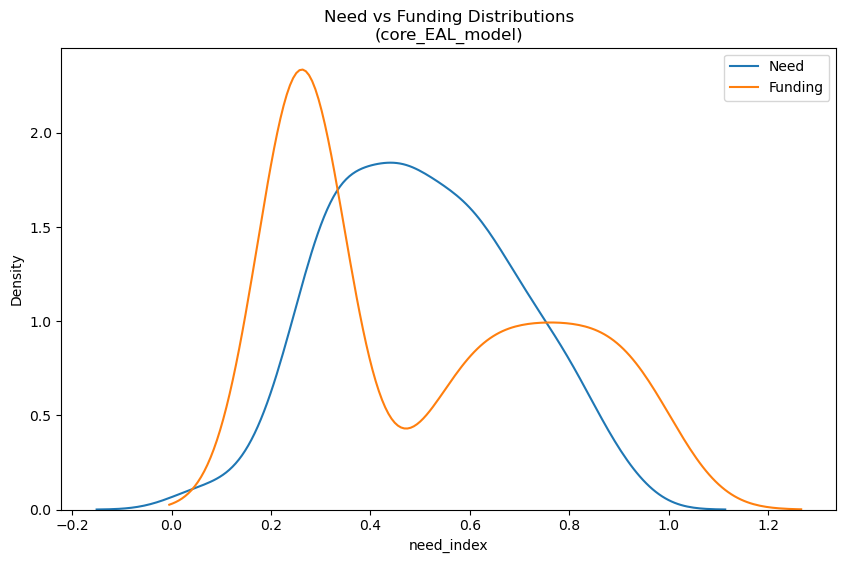

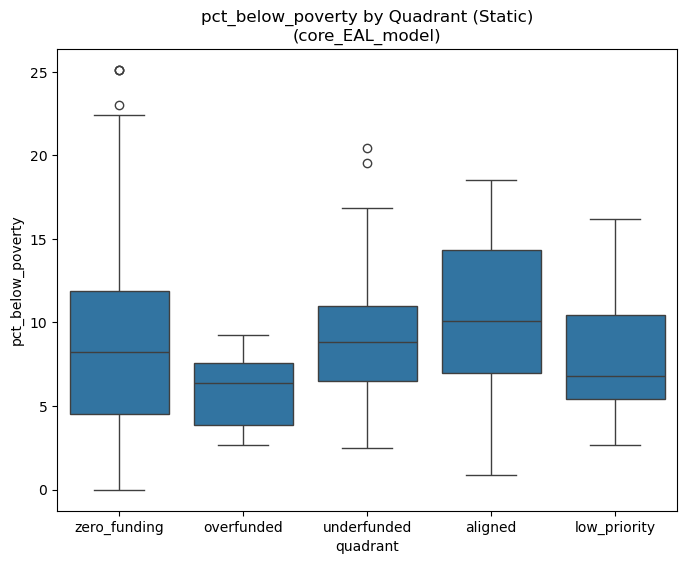

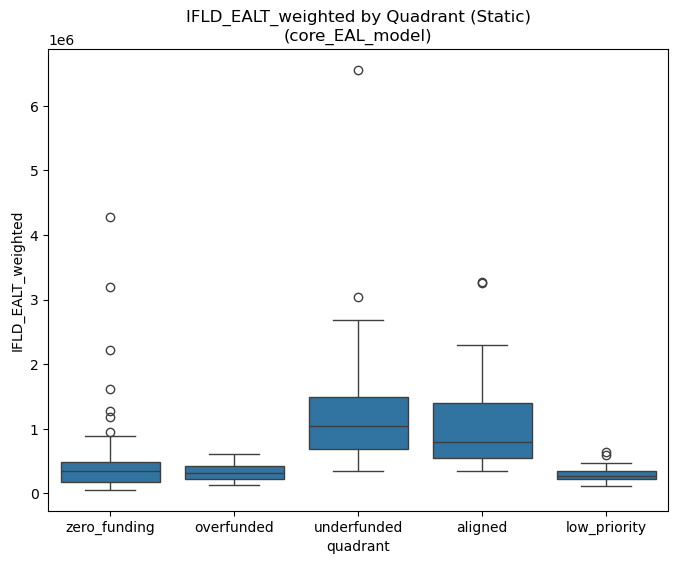

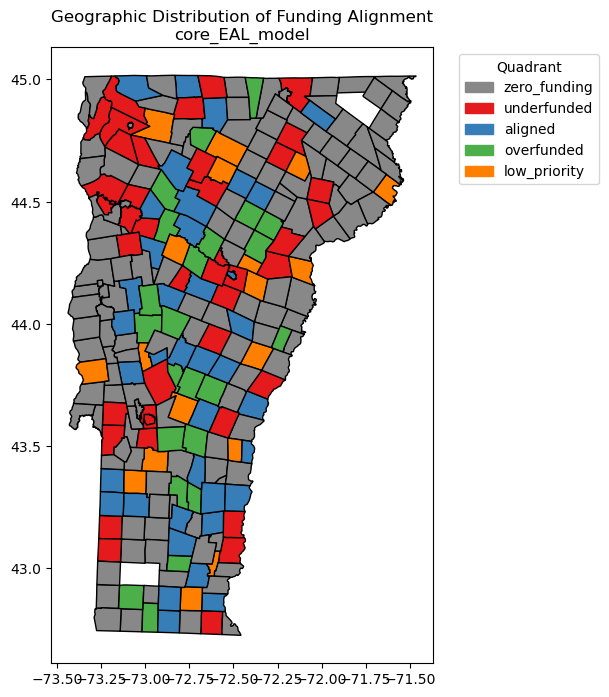

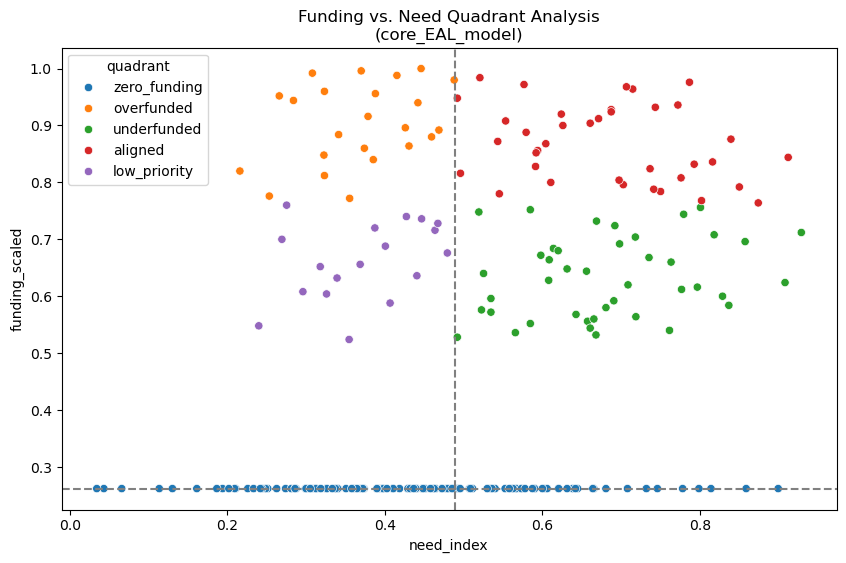

Top 10 towns by need rank:


,GEOID,town_name,need_rank,gap_rank,has_funding
179,5000363175,Searsburg town,1.0,192.0,False
9,5002702575,Baltimore town,2.0,191.0,False
228,5001577425,Waterville town,3.0,189.0,False
6,5000902125,Averill town,4.0,180.0,False
201,5002570750,Stratton town,5.0,179.0,False
193,5000762050,St. George town,6.0,176.0,False
202,5002171050,Sudbury town,7.0,173.0,False
121,5000942475,Maidstone town,8.0,170.0,False
195,5000369775,Stamford town,9.0,166.5,False
53,5000116000,Cornwall town,10.0,163.0,False


Top 10 towns by gap rank (overfunded):


,GEOID,town_name,need_rank,gap_rank,has_funding
16,5000304825,Bennington town,247.0,1.0,False
142,5001948850,Newport city,245.0,2.0,False
122,5000342850,Manchester town,237.0,3.0,False
183,5000764300,Shelburne town,234.0,4.0,False
140,5001748175,Newbury town,229.0,5.0,False
191,5001161675,St. Albans city,222.0,6.0,False
29,5000908725,Brighton town,217.0,7.0,False
188,5000766175,South Burlington city,212.0,8.0,False
68,5000724400,Essex Junction city,202.5,9.0,False
160,5000357025,Pownal town,197.5,10.0,False



~~~

=== core_model ===

Share of high-need towns with zero funding: 41.60%
Share of low-need towns with zero funding: 62.40%
Difference: -20.80%
Risk variables: ['pct_river_corridor']
Vulnerability variables: ['pct_below_poverty', 'percent_elderly', 'pct_no_vehicle']
Funding variable: log_funding_per_capita


,risk_index,vuln_index,need_index,funding_scaled,gap_index
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,0.502000,0.502000,0.502000,0.502000,1.021405e-17
std,0.289251,0.186257,0.184218,0.268147,2.920744e-01
min,0.012000,0.024667,0.035333,0.262000,-5.820000e-01
25%,0.253000,0.370000,0.364667,0.262000,-2.050000e-01
50%,0.502000,0.517333,0.489333,0.262000,-4.466667e-02
75%,0.751000,0.636000,0.654500,0.751000,2.263333e-01
max,1.000000,0.921333,0.910000,1.000000,6.840000e-01


,quadrant,count,share
0,zero_funding,130,0.520
1,aligned,40,0.160
2,underfunded,33,0.132
3,low_priority,27,0.108
4,overfunded,20,0.080


zero_funding,False,True
high_need,,
False,0.376,0.624
True,0.584,0.416


,pct_below_poverty,IFLD_EALT_weighted
quadrant,,
aligned,9.471126,9.691450e+05
low_priority,7.348342,5.566981e+05
overfunded,7.125388,3.804272e+05
underfunded,10.246862,1.328565e+06
zero_funding,8.986989,4.365639e+05


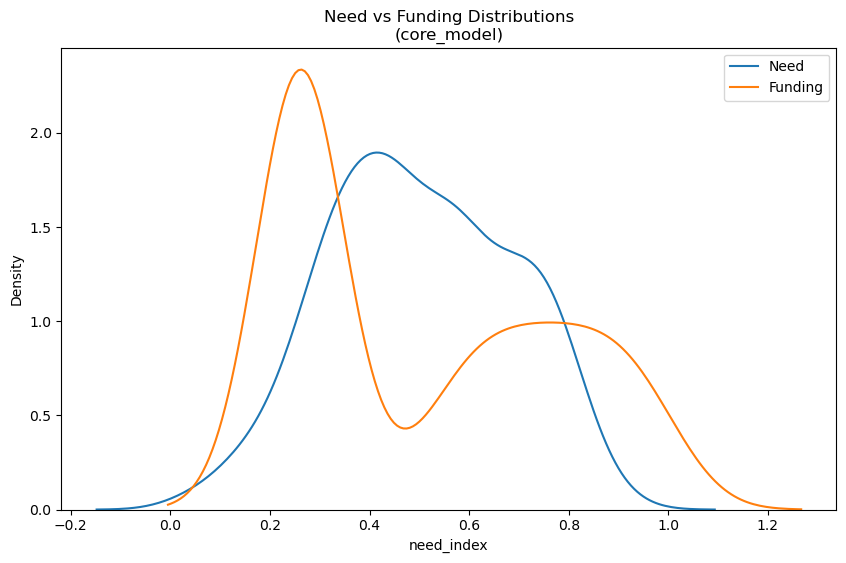

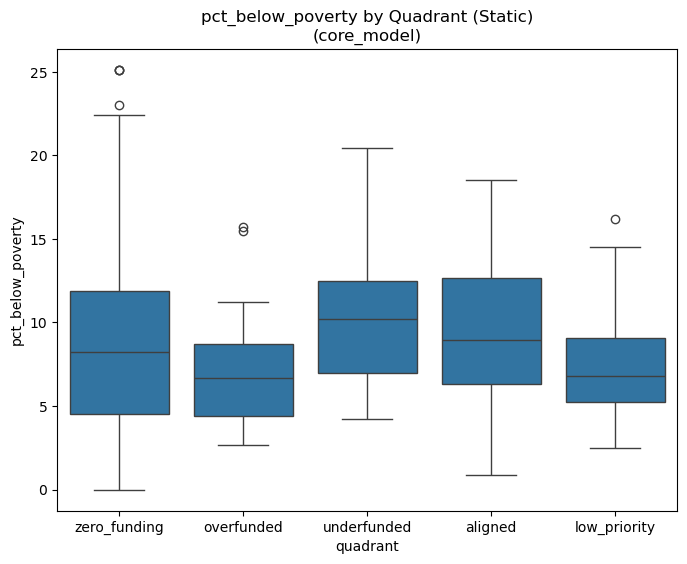

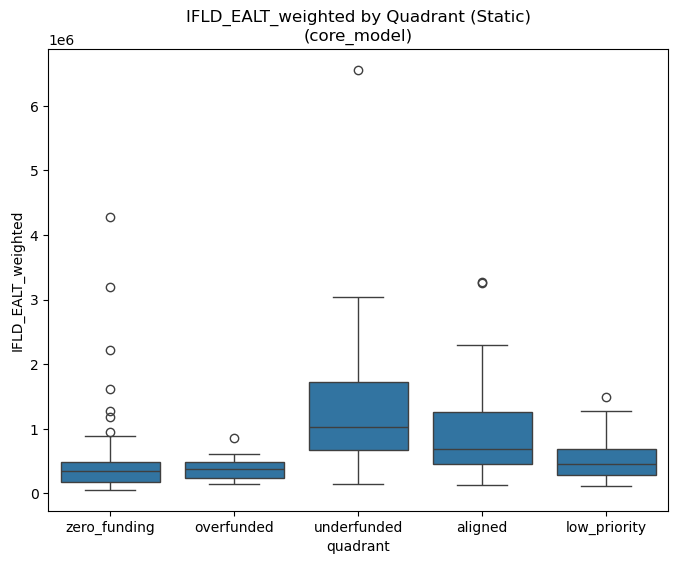

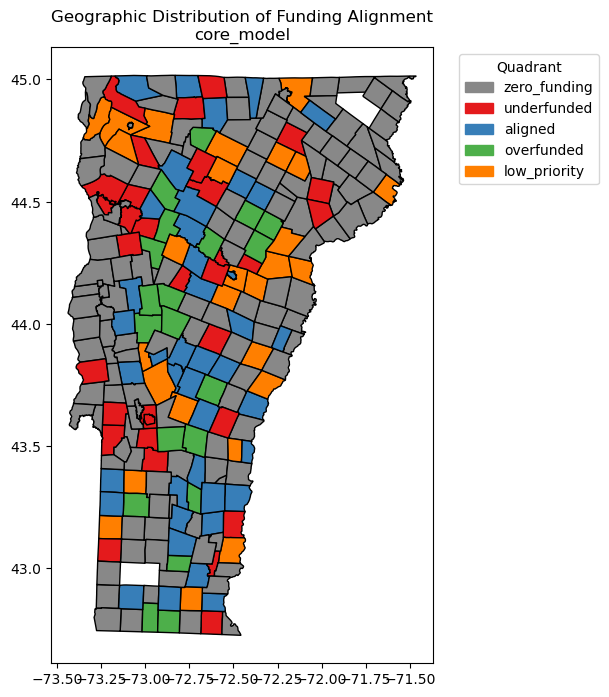

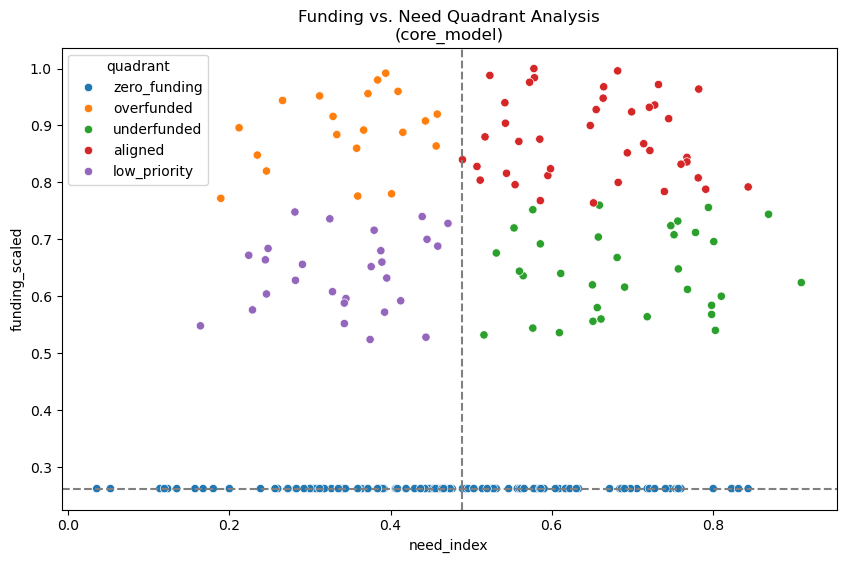

Top 10 towns by need rank:


,GEOID,town_name,need_rank,gap_rank,has_funding
9,5002702575,Baltimore town,1.0,188.0,False
201,5002570750,Stratton town,2.0,183.0,False
6,5000902125,Averill town,3.0,170.0,False
85,5001329275,Grand Isle town,4.0,168.0,False
66,5001523725,Elmore town,5.0,167.0,False
153,5000355000,Peru town,6.0,165.0,False
193,5000762050,St. George town,7.0,161.0,False
65,5001523500,Eden town,8.0,221.0,True
74,5002325825,Fayston town,9.0,159.0,False
195,5000369775,Stamford town,10.0,156.0,False


Top 10 towns by gap rank (overfunded):


,GEOID,town_name,need_rank,gap_rank,has_funding
161,5002157250,Proctor town,247.5,1.0,False
213,5000174650,Vergennes city,246.0,2.0,False
16,5000304825,Bennington town,245.0,3.0,False
54,5001916150,Coventry town,244.0,4.0,False
112,5000139325,Leicester town,240.0,5.0,False
142,5001948850,Newport city,229.0,6.0,False
242,5000183800,Whiting town,227.0,7.0,False
155,5002155600,Pittsford town,224.5,8.0,False
122,5000342850,Manchester town,223.0,9.0,False
68,5000724400,Essex Junction city,220.0,10.0,False



~~~

=== eal_per_capita_model ===

Share of high-need towns with zero funding: 45.60%
Share of low-need towns with zero funding: 58.40%
Difference: -12.80%
Risk variables: ['EAL_per_capita']
Vulnerability variables: ['pct_below_poverty', 'percent_elderly', 'pct_no_vehicle']
Funding variable: log_funding_per_capita


,risk_index,vuln_index,need_index,funding_scaled,gap_index
count,250.000000,250.000000,250.000000,250.000000,2.500000e+02
mean,0.502000,0.502000,0.502000,0.502000,5.329071e-18
std,0.289242,0.186257,0.177312,0.268147,2.922798e-01
min,0.004000,0.024667,0.132000,0.262000,-6.066667e-01
25%,0.251500,0.370000,0.356833,0.262000,-2.097500e-01
50%,0.503000,0.517333,0.498333,0.262000,-1.650000e-02
75%,0.746000,0.636000,0.638333,0.751000,2.301667e-01
max,1.000000,0.921333,0.924667,1.000000,6.890000e-01


,quadrant,count,share
0,zero_funding,130,0.520
1,aligned,41,0.164
2,low_priority,33,0.132
3,underfunded,27,0.108
4,overfunded,19,0.076


zero_funding,False,True
high_need,,
False,0.416,0.584
True,0.544,0.456


,pct_below_poverty,IFLD_EALT_weighted
quadrant,,
aligned,9.385061,8.449513e+05
low_priority,8.208288,1.069028e+06
overfunded,7.187647,6.174389e+05
underfunded,9.839932,8.739099e+05
zero_funding,8.986989,4.365639e+05


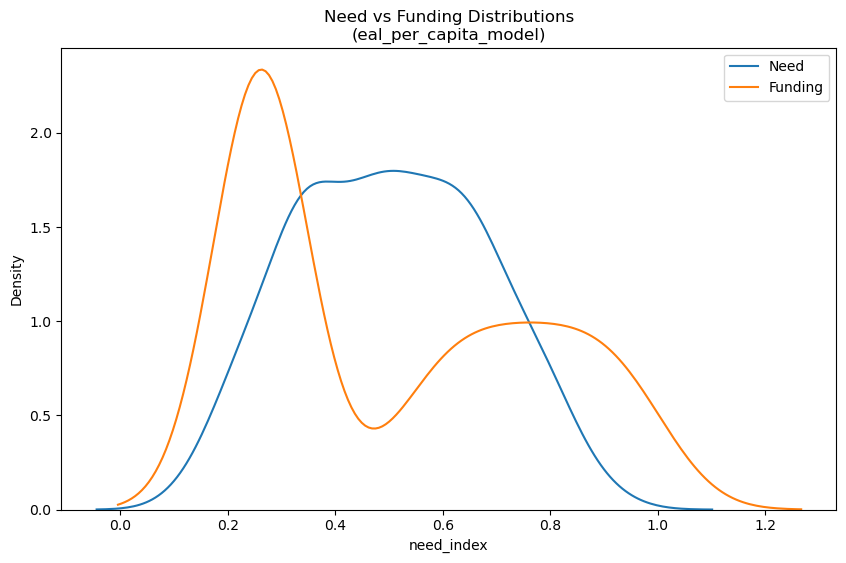

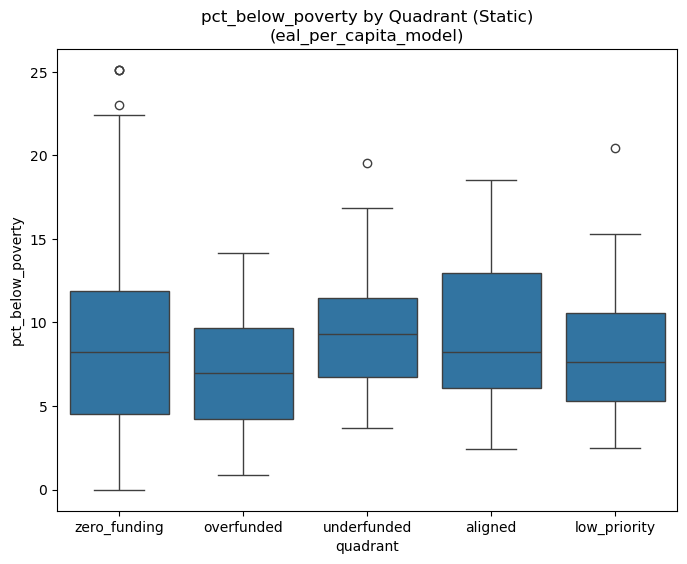

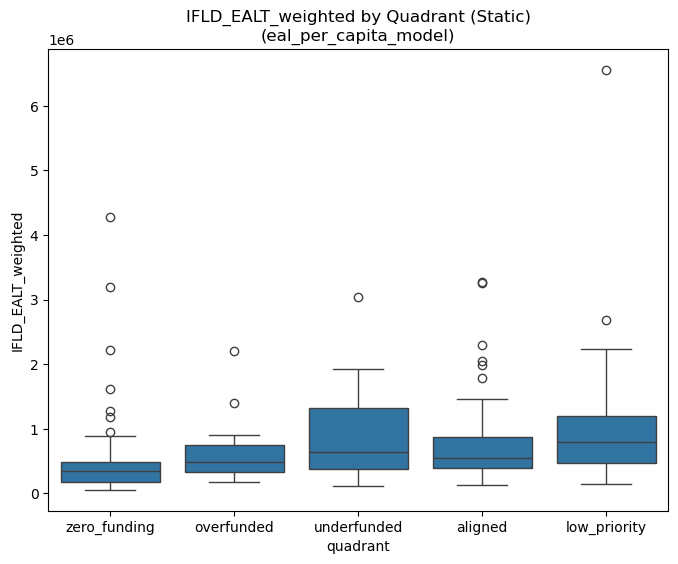

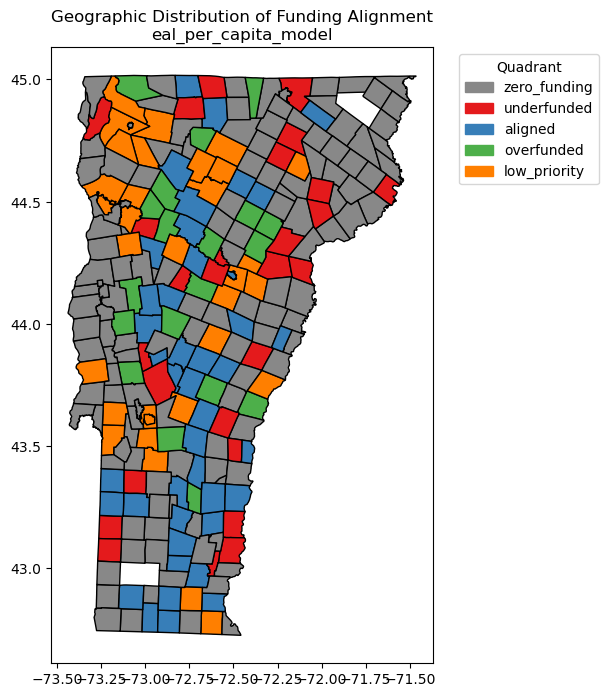

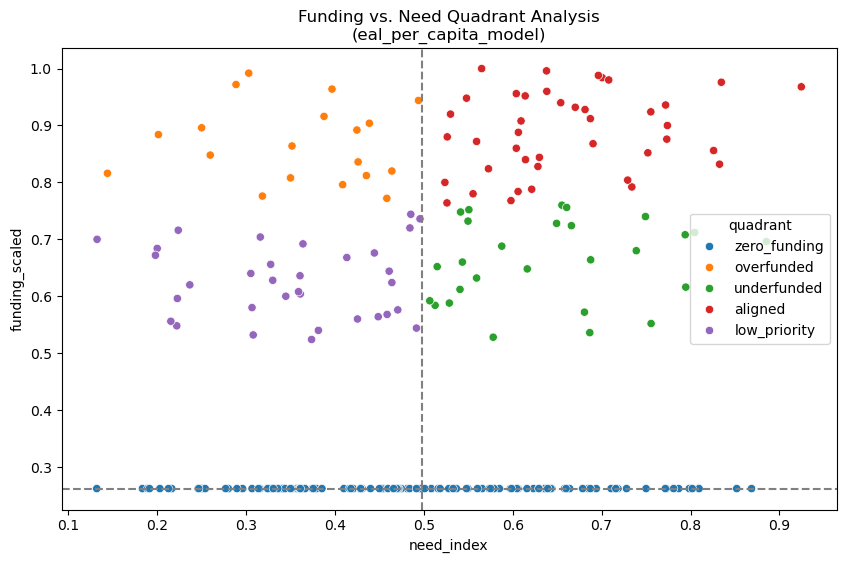

Top 10 towns by need rank:


,GEOID,town_name,need_rank,gap_rank,has_funding
64,5002321925,East Montpelier town,1.0,165.0,False
72,5001125225,Fairfield town,2.0,244.0,True
107,5000736700,Jericho town,3.0,247.0,True
129,5000745250,Milton town,4.0,152.5,False
130,5000145550,Monkton town,5.0,149.0,False
193,5000762050,St. George town,6.0,146.0,False
192,5001161750,St. Albans town,7.0,238.0,True
13,5002303250,Barre town,8.0,239.0,True
22,5000706550,Bolton town,9.0,248.0,True
228,5001577425,Waterville town,10.0,144.0,False


Top 10 towns by gap rank (overfunded):


,GEOID,town_name,need_rank,gap_rank,has_funding
146,5000952750,Norton town,248.0,1.0,False
29,5000908725,Brighton town,247.0,2.0,False
87,5001930175,Greensboro town,243.0,3.0,False
73,5001725675,Fairlee town,242.0,4.0,False
113,5000939700,Lemington town,240.0,5.0,False
41,5000911800,Canaan town,239.0,6.0,False
5,5002501900,Athens town,236.0,7.0,False
104,5001335875,Isle La Motte town,235.0,8.0,False
35,5000710300,Buels gore,232.0,9.0,False
247,5002584850,Windham town,230.0,10.0,False



~~~

=== fema_national_risk_index ===

Share of high-need towns with zero funding: 43.75%
Share of low-need towns with zero funding: 60.66%
Difference: -16.91%
Risk variables: ['RISK_SCORE_avg']
Vulnerability variables: []
Funding variable: log_funding_per_capita


,risk_index,vuln_index,need_index,funding_scaled,gap_index
count,250.000000,250.0,250.000000,250.000000,250.000000
mean,0.502000,0.0,0.251000,0.502000,0.251000
std,0.289235,0.0,0.144618,0.268147,0.291383
min,0.004000,0.0,0.002000,0.262000,-0.230000
25%,0.253000,0.0,0.126500,0.262000,0.039000
50%,0.502000,0.0,0.251000,0.262000,0.205500
75%,0.748000,0.0,0.374000,0.751000,0.475000
max,1.000000,0.0,0.500000,1.000000,0.956000


,quadrant,count,share
0,zero_funding,130,0.520
1,underfunded,36,0.144
2,aligned,36,0.144
3,overfunded,24,0.096
4,low_priority,24,0.096


zero_funding,False,True
high_need,,
False,0.393443,0.606557
True,0.562500,0.437500


,pct_below_poverty,IFLD_EALT_weighted
quadrant,,
aligned,9.318625,9.466055e+05
low_priority,7.951935,1.193525e+06
overfunded,7.745095,5.123561e+05
underfunded,9.602923,8.396916e+05
zero_funding,8.986989,4.365639e+05


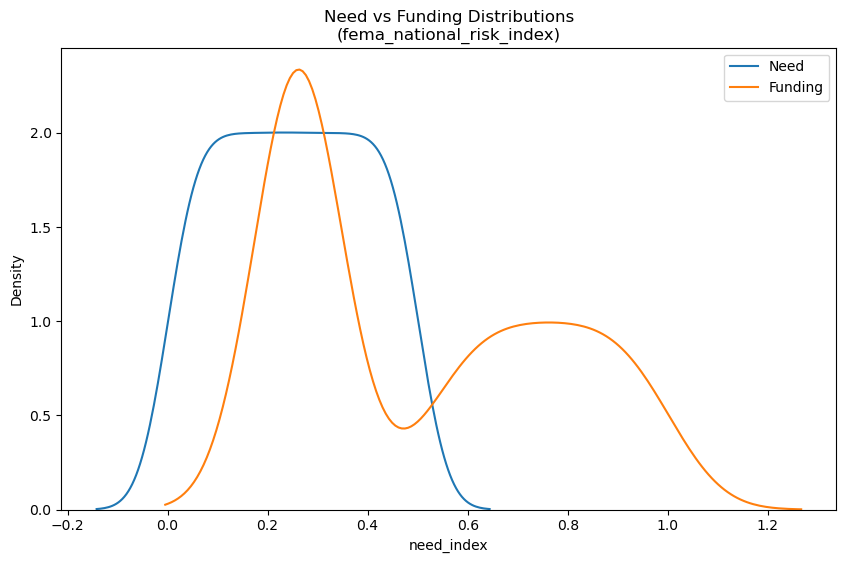

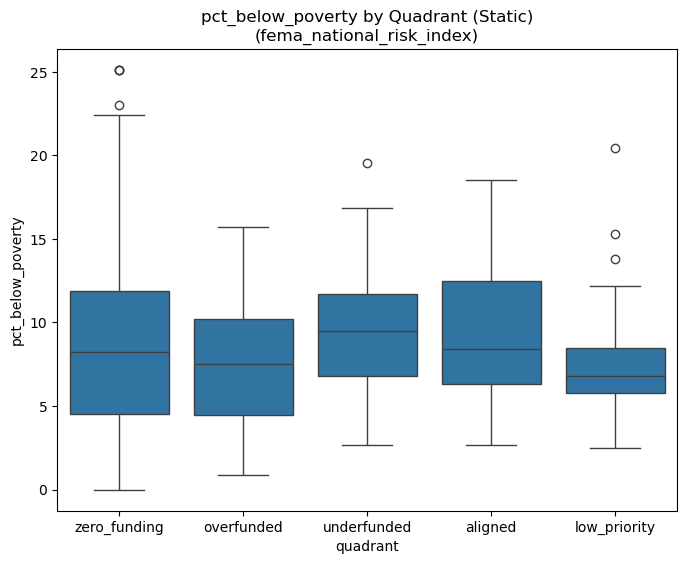

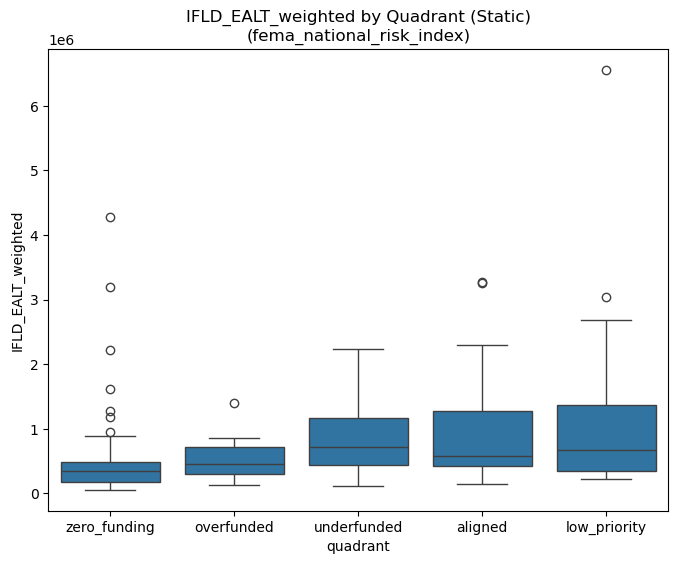

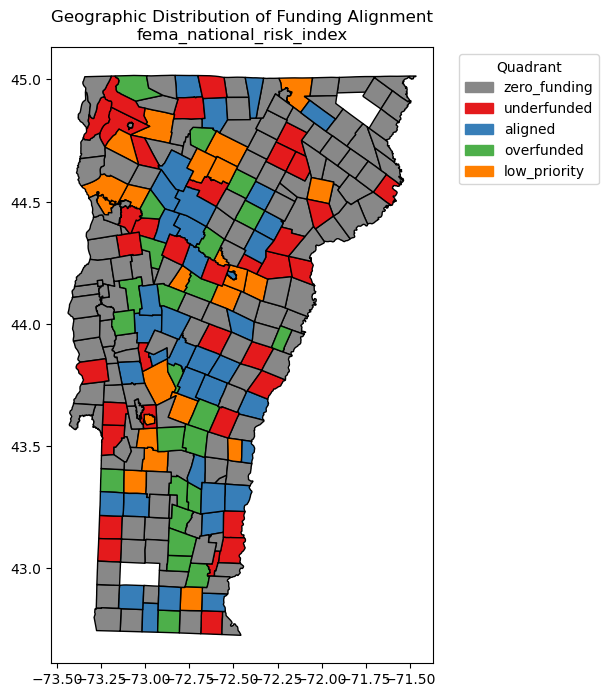

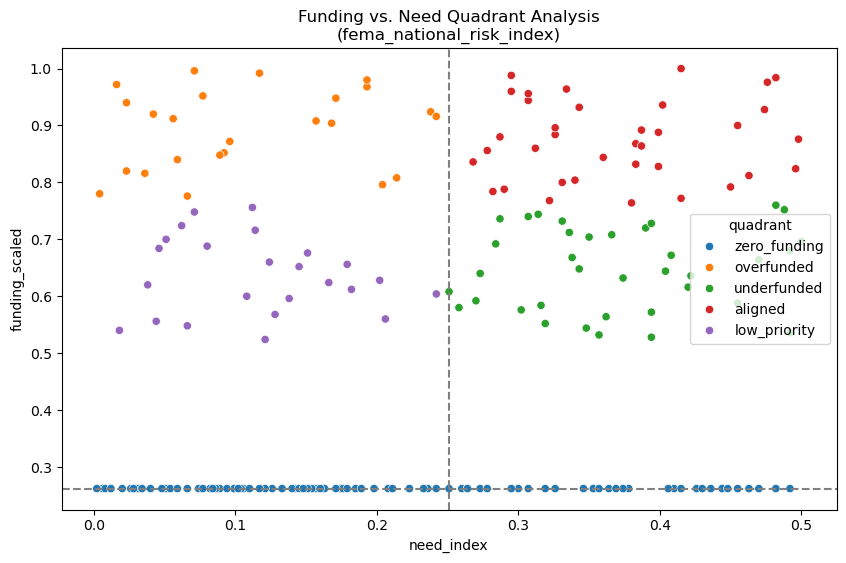

Top 10 towns by need rank:


,GEOID,town_name,need_rank,gap_rank,has_funding
74,5002325825,Fayston town,1.0,145.0,False
243,5002583950,Whitingham town,2.0,237.5,True
64,5002321925,East Montpelier town,3.0,143.0,False
161,5002157250,Proctor town,4.0,142.0,False
102,5002135425,Ira town,6.0,140.0,False
128,5002144800,Middletown Springs town,6.0,140.0,False
207,5002172925,Tinmouth town,6.0,140.0,False
96,5001133025,Highgate town,8.0,250.0,True
250,5000785150,Winooski city,9.0,202.0,True
29,5000908725,Brighton town,10.0,138.0,False


Top 10 towns by gap rank (overfunded):


,GEOID,town_name,need_rank,gap_rank,has_funding
203,5000371425,Sunderland town,246.0,1.0,False
5,5002501900,Athens town,241.0,3.0,False
247,5002584850,Windham town,241.0,3.0,False
209,5002573300,Townshend town,241.0,3.0,False
2,5001300860,Alburgh town,235.0,5.5,False
104,5001335875,Isle La Motte town,235.0,5.5,False
143,5001948925,Newport town,231.5,8.0,False
106,5001936325,Jay town,231.5,8.0,False
235,5001980200,Westfield town,231.5,8.0,False
211,5001773675,Tunbridge town,227.5,10.5,False



~~~



In [10]:
# run models
results = analyze_models(df, model_specs, gdf=gdf, display_results=True)

## Sanity checks

In [11]:
def plot_model_results(results, display_tables=True):
    """Create comparative plots of need vs funding and other key relationships for each model specification.

    Args:
        results (dict): Dictionary containing results for each model specification.
        display_tables (bool): Whether to display crosstab tables for quadrant vs insurance penetration.
    """
    for name, res in results.items():
        print(f"=== {name} ===")
        # merge quadrant info into results for plotting
        df_results = res["df_results"].merge(
            res["quadrants"][["GEOID", "quadrant"]], on="GEOID", how="left"
        )
        # create funding status category for boxplots
        df_results["funding_status"] = np.where(
            df_results["has_funding"] == 0, "zero", "funded"
        )

        # Boxplot: need_index by funding_status
        plt.figure()
        sns.boxplot(data=df_results, x="funding_status", y="need_index")
        plt.title(name)
        plt.show()

        # Boxplot: gap_index by funding_status
        plt.figure()
        sns.boxplot(data=df_results, x="funding_status", y="gap_index", color="orange")
        plt.title(name)
        plt.show()

        # Scatter: need vs funding (funded only)
        df_funded = df_results[df_results["has_funding"] > 0]
        plt.figure()
        sns.regplot(data=df_funded, x="need_index", y="funding_scaled")
        plt.title(name)
        plt.show()

        # Scatter: need vs population
        plt.figure()
        sns.regplot(
            data=df_results,
            x="need_index",
            y="total_population",
            scatter_kws={"alpha": 0.3},
            color="green",
        )
        plt.title(name)
        plt.show()

        # Scatter: need vs insurance claims
        plt.figure()
        sns.regplot(
            data=df_results,
            x="need_index",
            y="claims_paid_per_capita",
            scatter_kws={"alpha": 0.3},
        )
        plt.title(name)
        plt.show()

        # Crosstab: quadrant vs insurance penetration
        df_results["has_insurance"] = df_results["current_insurance_penetration"] > 0
        if display_tables:
            display(
                pd.crosstab(
                    df_results["quadrant"],
                    df_results["has_insurance"],
                    normalize="index",
                )
            )

        # Median and mean insurance penetration rate by quadrant
        penetration_stats = (
            df_results.groupby("quadrant")["current_insurance_penetration"]
            .agg(["median", "mean", "min", "max", "count"])
            .sort_index()
        )
        display(penetration_stats)

=== core_EAL_model ===


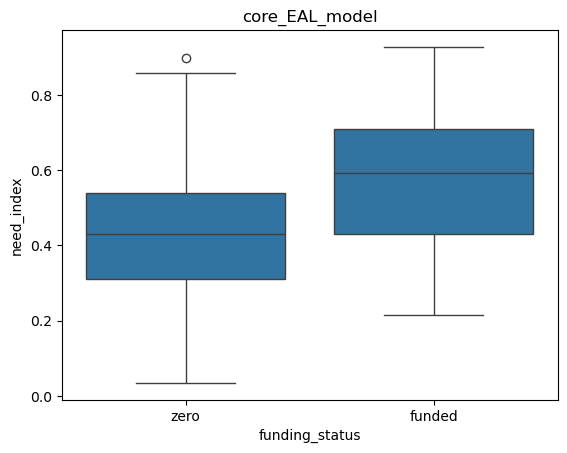

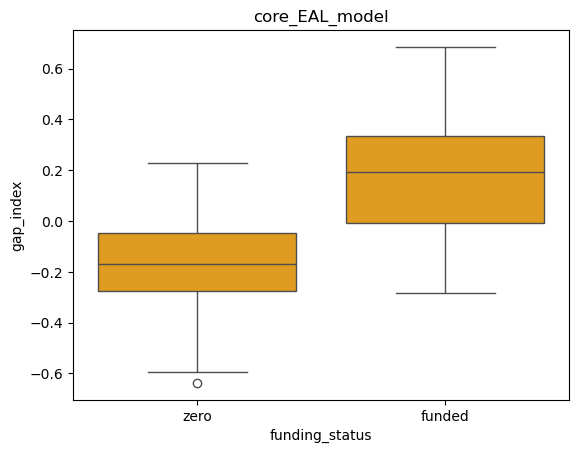

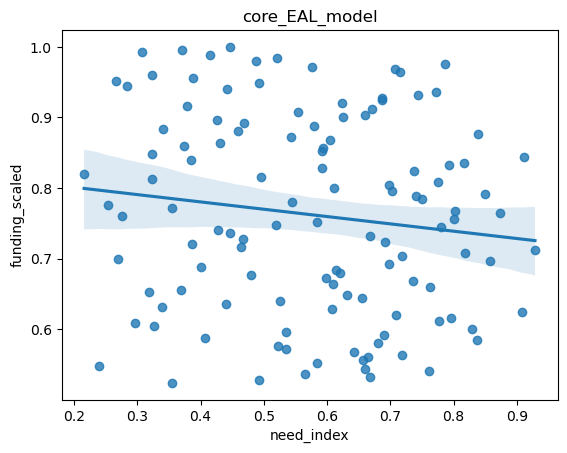

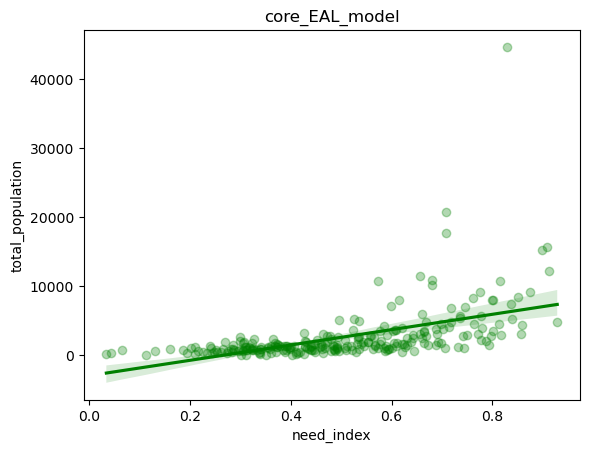

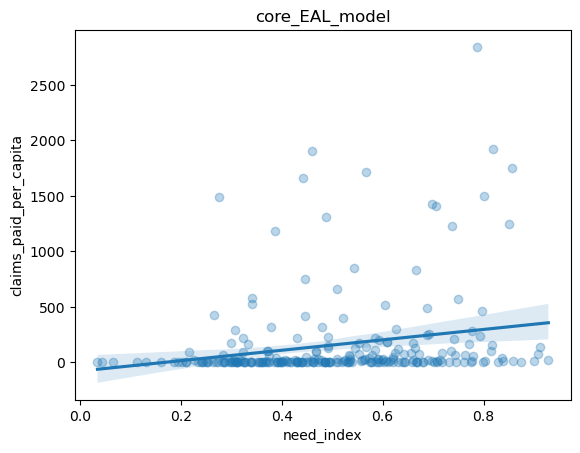

has_insurance,False,True
quadrant,,
aligned,0.027027,0.972973
low_priority,0.222222,0.777778
overfunded,0.043478,0.956522
underfunded,0.047619,0.952381
zero_funding,0.284615,0.715385


,median,mean,min,max,count
quadrant,,,,,
aligned,0.018961,0.030769,0.0,0.239829,37
low_priority,0.009111,0.011219,0.0,0.034956,18
overfunded,0.022758,0.025430,0.0,0.079295,23
underfunded,0.007013,0.014681,0.0,0.066649,42
zero_funding,0.005629,0.009372,0.0,0.087146,130


=== core_model ===


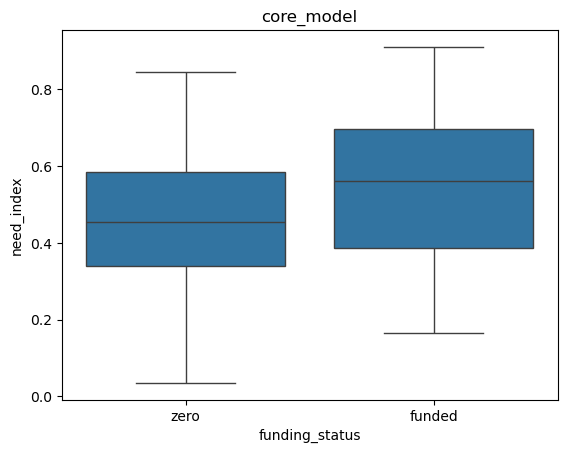

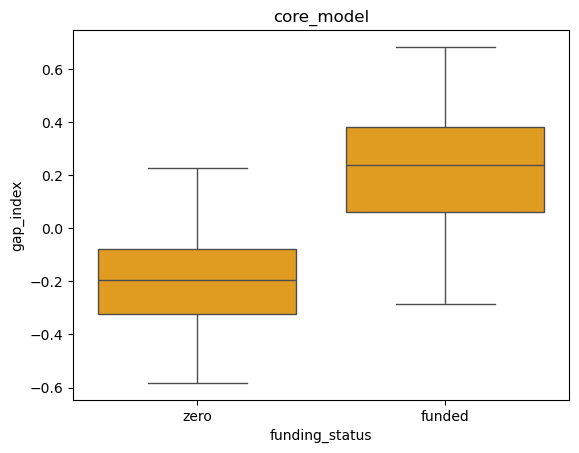

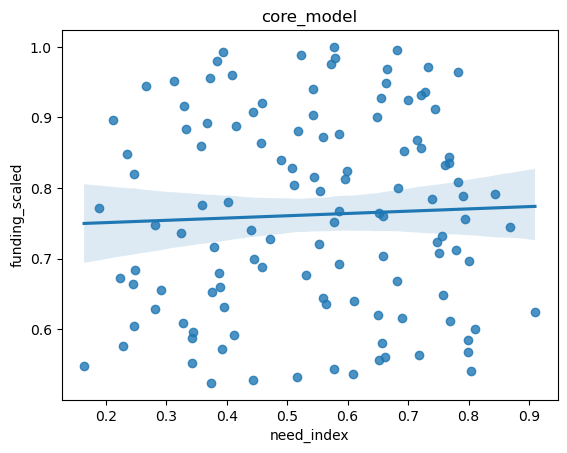

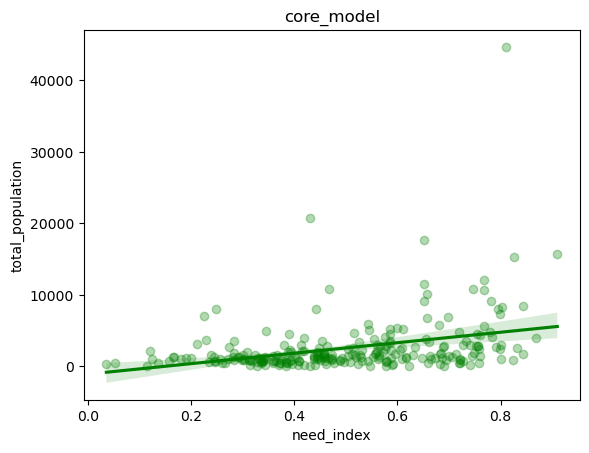

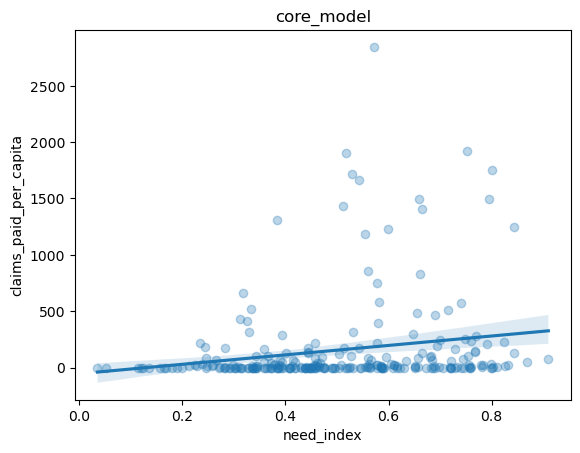

has_insurance,False,True
quadrant,,
aligned,0.050000,0.950000
low_priority,0.222222,0.777778
overfunded,0.000000,1.000000
underfunded,0.000000,1.000000
zero_funding,0.284615,0.715385


,median,mean,min,max,count
quadrant,,,,,
aligned,0.020703,0.030918,0.000000,0.239829,40
low_priority,0.008214,0.011089,0.000000,0.055985,27
overfunded,0.022807,0.024330,0.002564,0.079295,20
underfunded,0.008267,0.015731,0.000731,0.066649,33
zero_funding,0.005629,0.009372,0.000000,0.087146,130


=== eal_per_capita_model ===


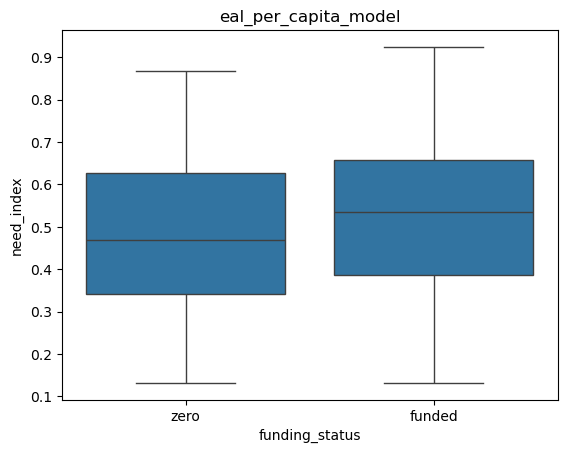

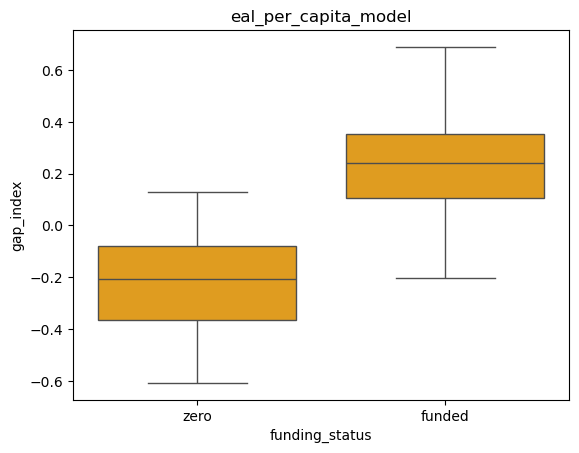

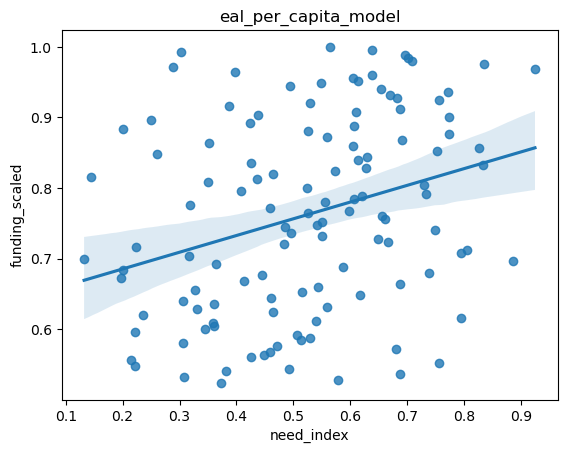

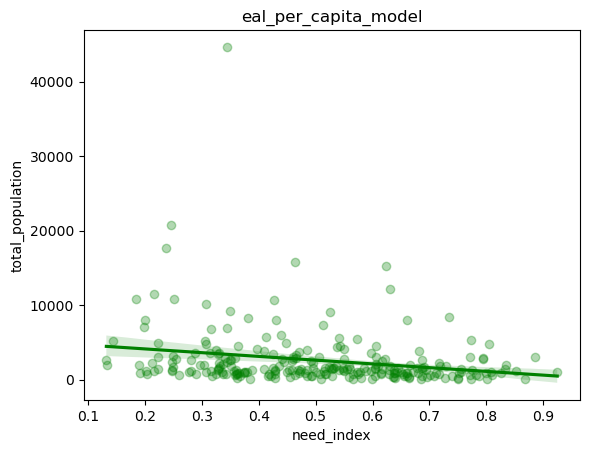

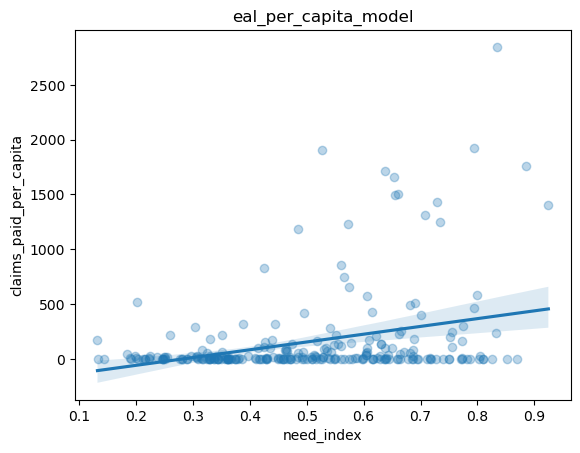

has_insurance,False,True
quadrant,,
aligned,0.048780,0.951220
low_priority,0.121212,0.878788
overfunded,0.000000,1.000000
underfunded,0.074074,0.925926
zero_funding,0.284615,0.715385


,median,mean,min,max,count
quadrant,,,,,
aligned,0.026738,0.034107,0.000000,0.239829,41
low_priority,0.005698,0.008370,0.000000,0.034956,33
overfunded,0.011807,0.017102,0.004231,0.051020,19
underfunded,0.015306,0.020086,0.000000,0.066649,27
zero_funding,0.005629,0.009372,0.000000,0.087146,130


=== fema_national_risk_index ===


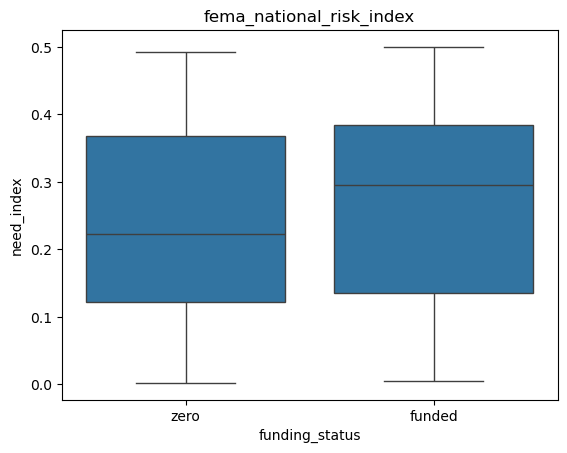

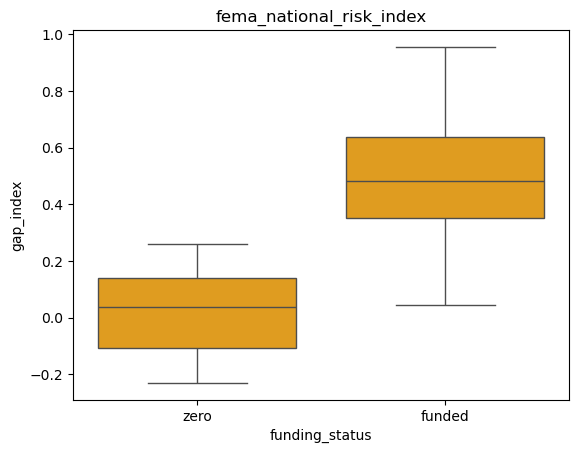

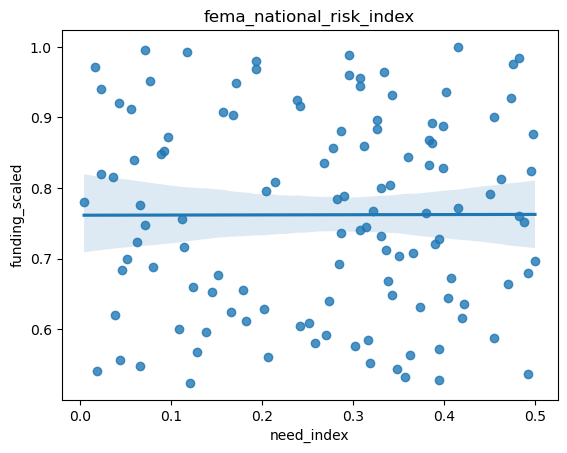

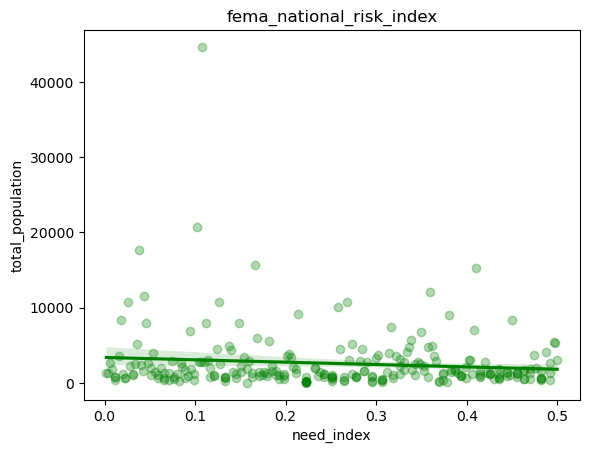

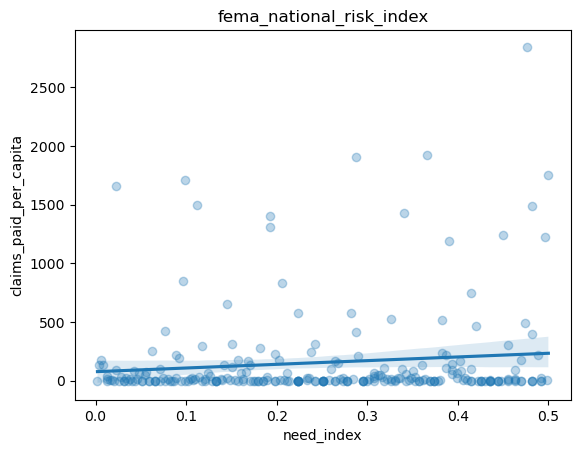

has_insurance,False,True
quadrant,,
aligned,0.055556,0.944444
low_priority,0.125000,0.875000
overfunded,0.000000,1.000000
underfunded,0.083333,0.916667
zero_funding,0.284615,0.715385


,median,mean,min,max,count
quadrant,,,,,
aligned,0.020703,0.028583,0.000000,0.239829,36
low_priority,0.005796,0.011226,0.000000,0.066649,24
overfunded,0.024034,0.028932,0.004762,0.107383,24
underfunded,0.011383,0.015253,0.000000,0.055985,36
zero_funding,0.005629,0.009372,0.000000,0.087146,130


In [12]:
# plot model results
plot_model_results(results)

## Model Comparisons

In [13]:
# create summary dataframe comparing quadrant distributions and zero funding analysis across models
summary_rows = []

# extract key summary metrics for each model to compare them in a single table
for name, res in results.items():
    # extract quadrant summary
    q = res["quadrant_summary"].set_index("quadrant")

    # add row to summary with quadrant shares and zero funding analysis results
    summary_rows.append(
        {
            "model": name,
            "zero_funding": q.loc["zero_funding", "share"],
            "underfunded": q.loc["underfunded", "share"],
            "aligned": q.loc["aligned", "share"],
            "overfunded": q.loc["overfunded", "share"],
            "low_priority": q.loc["low_priority", "share"],
            "pct_high_need_zero": res["zero_funding_analysis"]["pct_high_need_zero"],
            "gap_high_vs_low": res["zero_funding_analysis"]["gap"],
        }
    )

# convert to summary dataframe and sort by share of high-need towns with zero funding
summary_df = pd.DataFrame(summary_rows).sort_values(
    "pct_high_need_zero", ascending=False
)
display(summary_df)

,model,zero_funding,underfunded,aligned,overfunded,low_priority,pct_high_need_zero,gap_high_vs_low
2,eal_per_capita_model,0.52,0.108,0.164,0.076,0.132,0.4560,-0.128000
3,fema_national_risk_index,0.52,0.144,0.144,0.096,0.096,0.4375,-0.169057
1,core_model,0.52,0.132,0.160,0.080,0.108,0.4160,-0.208000
0,core_EAL_model,0.52,0.168,0.148,0.092,0.072,0.3680,-0.304000


In [14]:
# identify top 20 towns by gap index for each model and compare overlaps
top_sets = {}

for name, res in results.items():
    df_r = res["df_results"]
    # get GEOIDs of top 20 towns with lowest gap index (most underfunded relative to need)
    top_sets[name] = set(df_r.nsmallest(20, "gap_index")["GEOID"])

# pairwise overlap
overlap = pd.DataFrame(index=top_sets.keys(), columns=top_sets.keys())

# compute overlap between top sets
for m1 in top_sets:
    for m2 in top_sets:
        # calcuate the percentage overlap between the top 20 sets of two models (length of intersection divided by 20)
        overlap.loc[m1, m2] = len(top_sets[m1] & top_sets[m2]) / 20

display(overlap)

,core_EAL_model,core_model,eal_per_capita_model,fema_national_risk_index
core_EAL_model,1.0,0.3,0.2,0.05
core_model,0.3,1.0,0.05,0.2
eal_per_capita_model,0.2,0.05,1.0,0.35
fema_national_risk_index,0.05,0.2,0.35,1.0


,core_EAL_model,core_model,eal_per_capita_model,fema_national_risk_index
core_EAL_model,1.000000,0.567896,0.281241,0.086303
core_model,0.567896,1.000000,0.226365,0.037351
eal_per_capita_model,0.281241,0.226365,1.000000,0.327887
fema_national_risk_index,0.086303,0.037351,0.327887,1.000000


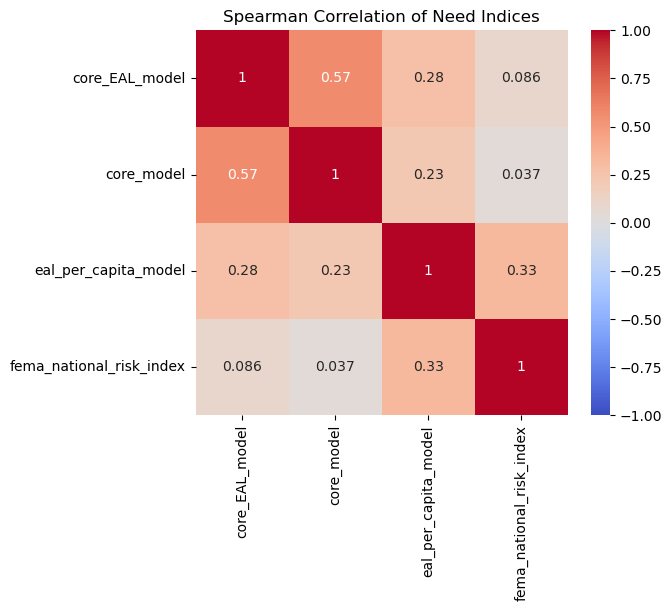

In [15]:
# compare need indices directly

# collect need_index for each model
need_indices = {name: res["df_results"]["need_index"] for name, res in results.items()}

# initialize an empty DataFrame
corr_matrix = pd.DataFrame(
    index=need_indices.keys(), columns=need_indices.keys(), dtype=float
)

# fill the matrix with Spearman correlations
for m1, s1 in need_indices.items():
    for m2, s2 in need_indices.items():
        corr_matrix.loc[m1, m2] = spearmanr(s1, s2)[0]

display(corr_matrix)

# plot heatmap of correlation matrix
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Spearman Correlation of Need Indices")
plt.show()

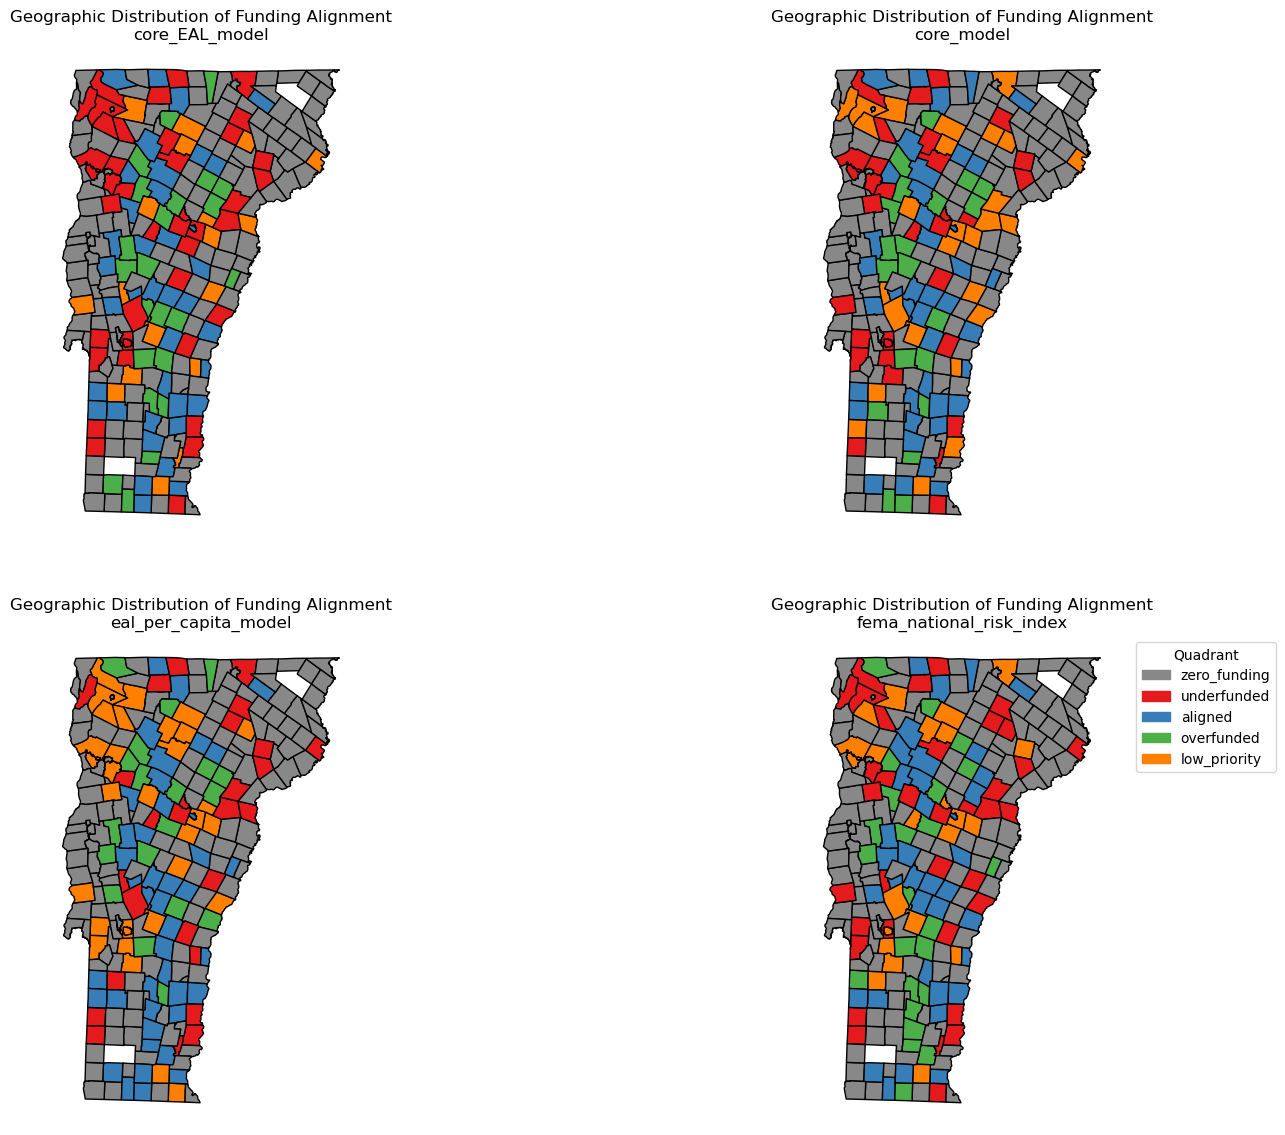

In [16]:
# print all four maps together for visual comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    plot_quadrant_map(res["quadrants"], gdf, name, ax=ax)
    ax.axis("off")